# 📊 Student Performance Analysis

This notebook performs Exploratory Data Analysis (EDA) on student data to uncover patterns in academic performance, attendance, and improvement trends.

---

## 🎯 Objectives
- Understand distribution of student marks
- Analyze impact of attendance
- Identify performance trends across terms
- Highlight top-performing students


## 📌 Dataset Overview

We begin by understanding the structure, data types, and summary statistics of the dataset.


In [24]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from db_connection import get_connection

sns.set(style="whitegrid")

In [26]:
def load_all_data():
    conn = get_connection()

    performance_summary = pd.read_sql("SELECT * FROM performance_summary", conn)
    performance_dist = pd.read_sql("SELECT * FROM performance_distribution", conn)
    attendance_dist = pd.read_sql("SELECT * FROM attendance_distribution", conn)
    top_students = pd.read_sql("SELECT * FROM top_students", conn)
    improvement_stats = pd.read_sql("SELECT * FROM improvement_stats", conn)
    correlation_matrix = pd.read_sql("SELECT * FROM correlation_matrix", conn)

    conn.close()

    return (
        performance_summary,
        performance_dist,
        attendance_dist,
        top_students,
        improvement_stats,
        correlation_matrix
    )

(
    performance_summary,
    performance_dist,
    attendance_dist,
    top_students,
    improvement_stats,
    correlation_matrix
) = load_all_data()


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7852\1432080849.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  performance_summary = pd.read_sql("SELECT * FROM performance_summary", conn)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_7852\1432080849.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  performance_dist = pd.read_sql("SELECT * FROM performance_distribution", conn)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_7852\1432080849.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  attendance_dist = pd.read_sql("SEL

## 📊 Attendance Distribution

This visualization shows how students are distributed across attendance levels.

### 🔍 Insight:
- Majority of students fall under **high attendance**
- Very few students are in medium/low categories
- Dataset is skewed towards high attendance


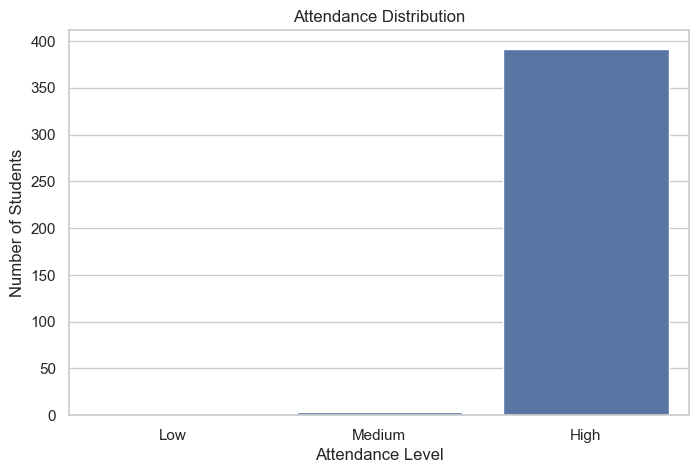

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='attendance_bucket',
    y='count',
    data=attendance_dist,
    order=['Low', 'Medium', 'High']
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance Level")
plt.ylabel("Number of Students")
plt.show()


## 📊 Average Marks Distribution

This visualization shows how student average marks are distributed.

### 🔍 Insight:
- Most students fall in the mid-score range
- Distribution is slightly normal
- Few extreme performers exist


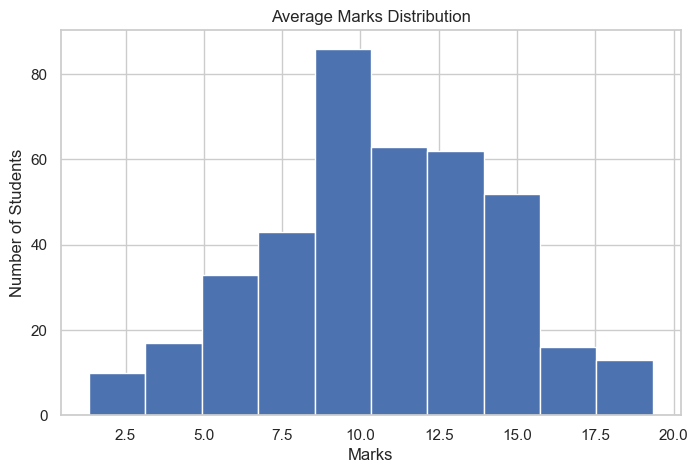

In [28]:
plt.figure(figsize=(8,5))
plt.hist(performance_summary['average_marks'], bins=10)
plt.title("Average Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()


## 📊 Performance Categories

This chart shows how students are distributed across performance categories.

### 🔍 Insight:
- Majority fall in average category
- Smaller groups in high and low performance


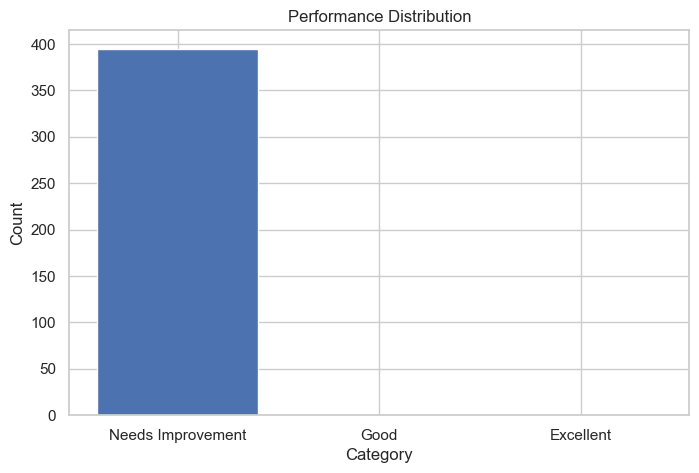

In [29]:
plt.figure(figsize=(8,5))
plt.bar(performance_dist['performance'], performance_dist['count'])
plt.title("Performance Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


## 📊 Attendance Distribution

This data comes from the ETL pipeline where attendance was bucketed.

### 🔍 Insight:
- Most students have high attendance
- Very few fall into low attendance


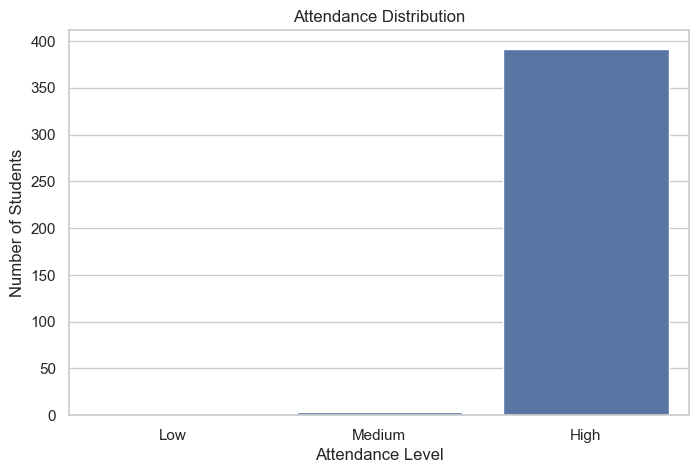

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='attendance_bucket',
    y='count',
    data=attendance_dist,
    order=['Low', 'Medium', 'High']
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance Level")
plt.ylabel("Number of Students")
plt.show()


## 🏆 Top 10 Students

This shows the highest-performing students based on average marks.

### 🔍 Insight:
- Top students consistently score high
- Small group of high achievers


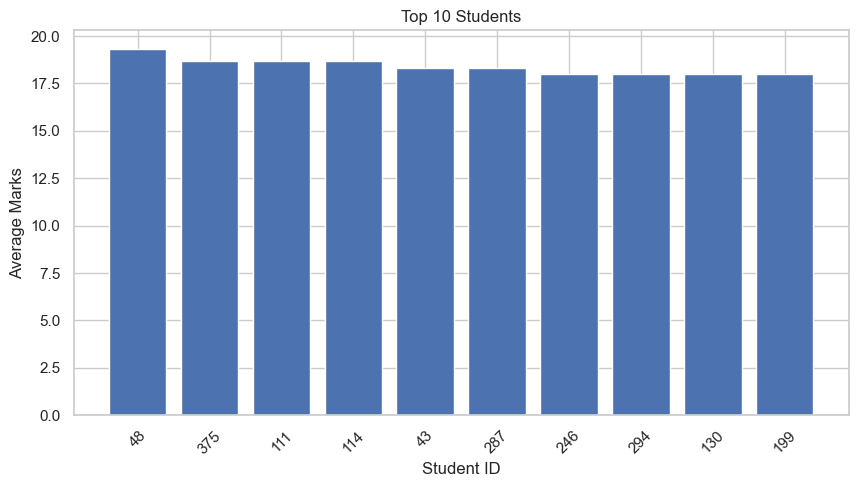

In [31]:
plt.figure(figsize=(10,5))
plt.bar(top_students['student_id'].astype(str), top_students['average_marks'])
plt.title("Top 10 Students")
plt.xlabel("Student ID")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.show()


## 📊 Performance Improvement

Shows how student performance changed from G1 to G3.

### 🔍 Insight:
- Most students show stable performance
- Few show strong improvement or decline


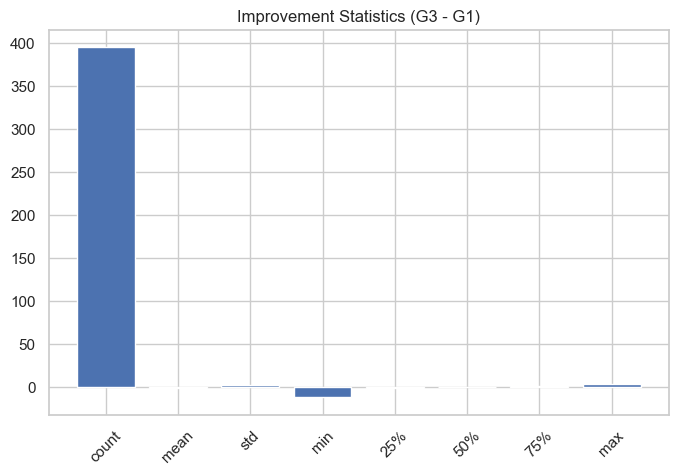

In [32]:
plt.figure(figsize=(8,5))
plt.bar(improvement_stats['metric'], improvement_stats['value'])
plt.title("Improvement Statistics (G3 - G1)")
plt.xticks(rotation=45)
plt.show()


## 📊 Correlation Analysis

Shows relationships between key academic metrics.

### 🔍 Insight:
- Strong correlation between G1, G2, G3
- Indicates consistent performance


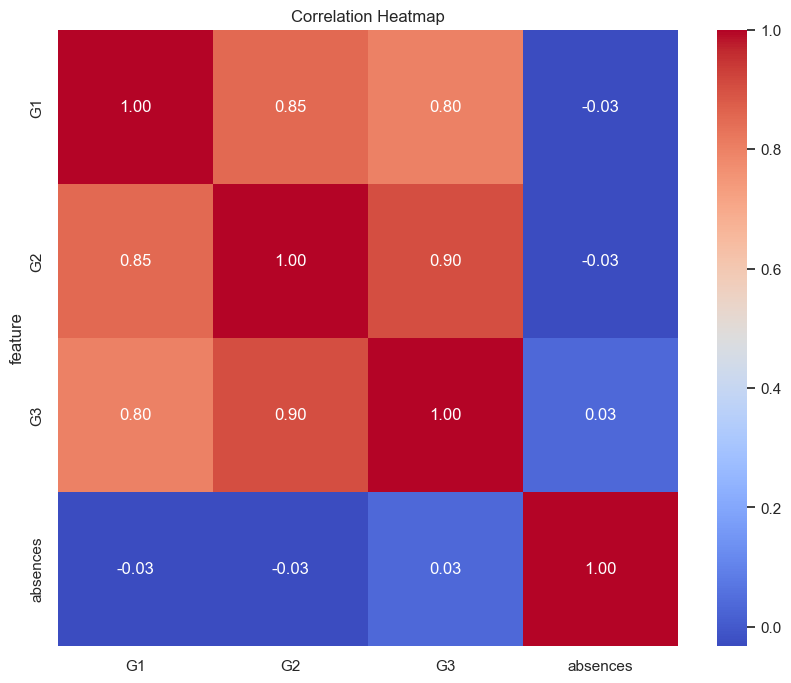

In [33]:
plt.figure(figsize=(10,8))

corr = correlation_matrix.set_index('feature')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 🧠 Final Insights

- Student performance is consistent across exams
- Attendance is generally high across dataset
- Most students fall into mid-performance category
- A small group of students dominate top scores

---

## 🚀 Conclusion

This notebook demonstrates how transformed data from a pipeline can be used to generate meaningful insights and visualizations.
